# INF 791 – Redes Complexas · Trabalho Prático Intermediário
## Rede de jogos da Steam que compartilham usuários
### Lucas Martins Souza - EF04235

---

### Descrição geral do trabalho
A **Steam** é uma plataforma de distribuição digital de jogos para computadores pessoais, reunindo atualmente mais de 132 milhões de usuários cadastrados e registrando um pico de 42,04 milhões de usuários simultâneos no início de 2026. Seu catálogo supera 230 mil títulos.

Neste trabalho foi construída uma rede que que representa jogos com usuários em comum:
- os nós representam títulos dos jogos
- as arestas representam a presença de usuários em comum
- a definição dos nós e do peso das arestas seguiu-se de uma análise de dados estatísticos do conjunto de dados bem como de avaliações empíricas de redes que gerariam grafos interessantes, visíveis e que suportassem as análises em tempo e espaço hábil (mais detalhes sobre estas definições serão explicados na montagem do grafo)

**Fonte dos dados**: Coleta realizada atravéz da APi pública da própria plataforma
> API: `https://steamcommunity.com/dev`

> plataforma: `https://store.steampowered.com`



## ETAPA 1

### 1a. Coleta de dados

A Etapa de coleta dos jogos está detalhada no código abaixo o qual foi executado previamente fora do ambiente do notebook

A coleta leva em consideração o uso de uma coleta anterior realizada para coletar informações dos usuários sendo verificado a principio usuários que tem pelo menos 1 jogo na conta. Após isso, tenta-se coletar os dados relacionados ao par usuário-jogo para cada usuário válido após o filtro tentando coletar estas informações por meio de threads para chamadas concorrentes e alternando a chave da API caso ocorra um "rate limite" e salvando as chamadas sucedidas em lotes.

À chamada da API usa de endpoint: https://api.steampowered.com/IPlayerService/GetOwnedGames/v1/,  onde "key" é uma das chaves utilizadas, "steamid" é o identificador extraído da URl do usuário, "include_appinfo=1" define o retorne de informações como nome e ícone do jogo e "include_played_free_games=1" inclui jogos gratuitos que o usuário já jogou

In [ ]:
import os
import pandas as pd
import time
import requests
import re
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import cycle

# ==============================
# 1️⃣ Carregamento de dados
# ==============================
def carregar_usuarios(caminho_parquet: str) -> pd.DataFrame:
    df = pd.read_parquet(caminho_parquet)
    print(f"Total de usuários (antes do filtro): {len(df)}")
    df = df[df["Total de Jogos"] > 0]
    print(f"Total de usuários (após filtro > 0 jogos): {len(df)}")
    return df

# ==============================
# 2️⃣ Coletar jogos via API
# ==============================
def coletar_jogos_steamapi(steamid: str, api_key: str):
    url = (
        "https://api.steampowered.com/IPlayerService/GetOwnedGames/v1/"
        f"?key={api_key}&steamid={steamid}&include_appinfo=1&include_played_free_games=1"
    )
    try:
        resp = requests.get(url, timeout=10)
        if resp.status_code in [420, 429]:
            # Retorna um indicador para trocar de chave
            return "RATE_LIMIT"
        if resp.status_code != 200:
            print(f"Erro ao consultar {steamid}: {resp.status_code}")
            return []
        jogos = []
        data = resp.json().get("response", {}).get("games", [])
        for g in data:
            jogo_info = g.copy()
            jogo_info["Usuario"] = steamid
            jogos.append(jogo_info)
        return jogos
    except requests.exceptions.RequestException as e:
        print(f"Erro de requisição {steamid}: {repr(e)}")
        return []

# ==============================
# 3️⃣ Coletar dados de todos os usuários com threads e checkpoint
# ==============================
def coletar_dados_api(df: pd.DataFrame, path_saida: str, api_keys: list, salvar_a_cada: int = 50,
                       checkpoint_path: str = "checkpoint.txt", max_threads: int = 10):
    # Lê checkpoint
    start_index = 0
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            last_index = f.read().strip()
            if last_index.isdigit():
                start_index = int(last_index)
                print(f"Retomando a partir do índice {start_index}")

    buffer_usuarios = []
    total = len(df)
    api_cycle = cycle(api_keys)  # Cicla entre as chaves
    api_key = next(api_cycle)

    with ThreadPoolExecutor(max_workers=max_threads) as executor:
        futures = {}
        for i in range(start_index, total):
            steamid = df.iloc[i]["Nome"]
            match = re.search(r'/profiles/(\d+)', steamid)
            if not match:
                print(f"URL inválida: {steamid}")
                continue
            steamid = match.group(1)

            # Tenta coletar jogos, alternando chaves se atingir limite
            while True:
                future = executor.submit(coletar_jogos_steamapi, steamid, api_key)
                result = future.result()
                if result == "RATE_LIMIT":
                    print(f"Chave {api_key} atingiu limite, trocando...")
                    api_key = next(api_cycle)
                    time.sleep(1)  # Pequena pausa antes de tentar nova chave
                else:
                    jogos = result
                    break

            buffer_usuarios.extend(jogos)
            print(f"[{i+1}/{total}] Coletados {len(jogos)} jogos")

            # Salvar a cada batch
            if (i - start_index + 1) % salvar_a_cada == 0:
                arquivo = os.path.join(path_saida, f"usuarios_batch_{i+1}.parquet")
                pd.DataFrame(buffer_usuarios).to_parquet(arquivo, index=False)
                print(f"Batch salvo: {arquivo} (usuários {i+1 - salvar_a_cada + 1} a {i+1})")
                buffer_usuarios = []

                # Atualiza checkpoint
                with open(checkpoint_path, "w") as f:
                    f.write(str(i+1))

    # Salva qualquer sobra no buffer
    if buffer_usuarios:
        arquivo = os.path.join(path_saida, f"usuarios_batch_final.parquet")
        pd.DataFrame(buffer_usuarios).to_parquet(arquivo, index=False)
        print(f"Último batch salvo: {arquivo}")

# ==============================
# 4️⃣ Função principal
# ==============================
def main():
    STEAM_API_KEYS = [


    ]
    path_entrada = r"D:\\steamWebScraper\\data-sets\\usuarios\\todos_usuarios1_completo.parquet"
    path_saida = r"D:\steamWebScraper\amigos\jogos dos usuarios\resultados"
    os.makedirs(path_saida, exist_ok=True)

    df = carregar_usuarios(path_entrada)
    coletar_dados_api(df, path_saida, api_keys=STEAM_API_KEYS)

# ==============================
# Execução
# ==============================
if __name__ == "__main__":
    main()


### 1b. Identificando e montando o grafo a ser analisado

Liberar acesso ao drive com os dados coletados

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Analise prévia dos dados para identificar possíveis grafos

Primeiramente, devido ao tamanho da base coletada foi feita uma distribuição de usuários por jogo visando identificar uma faixa que englobasse jogos com quantidades relativamente mais relevantes de jogadores e ao mesmo tempo evitando abordar os jogos extremamente populares que gerariam um grafo muito denso.

In [ ]:
import pandas as pd

# Caminho do arquivo
caminho = '/content/drive/MyDrive/Steam - redes complexas/jogos dos usuarios/jogos_usuarios_brasil.parquet'

# Ler apenas as colunas necessárias para economizar memória
df = pd.read_parquet(caminho, columns=['name', 'Usuario'])

In [ ]:
usuarios_por_jogo = df.groupby('name').size().reset_index(name='num_usuarios')

In [ ]:
estatisticas = usuarios_por_jogo['num_usuarios'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95])
print(estatisticas)

count     43325.000000
mean        612.184535
std        3339.904572
min           1.000000
25%           5.000000
50%          27.000000
75%         155.000000
90%         788.000000
95%        2190.600000
max      152098.000000
Name: num_usuarios, dtype: float64


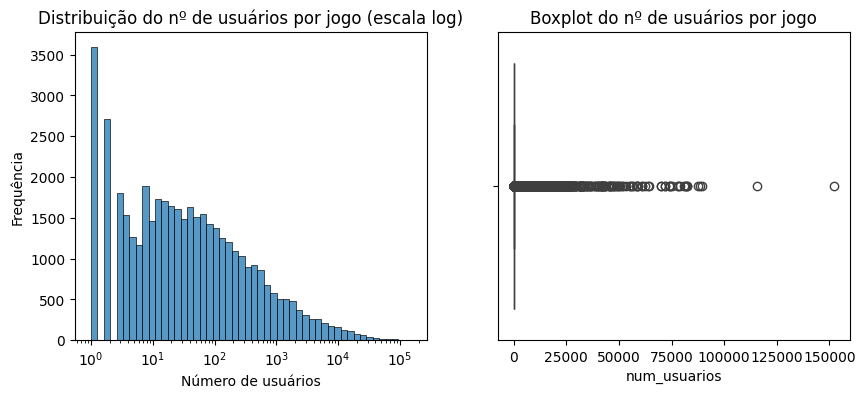

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(usuarios_por_jogo['num_usuarios'], bins=50, log_scale=True)
plt.title('Distribuição do nº de usuários por jogo (escala log)')
plt.xlabel('Número de usuários')
plt.ylabel('Frequência')

plt.subplot(1,2,2)
sns.boxplot(x=usuarios_por_jogo['num_usuarios'])
plt.title('Boxplot do nº de usuários por jogo')
plt.show()

Dessa forma, observando-se os dados da distribuição e obsrvou-se que para cerca de metade dos dados a quantidade de usuários variava muito pouco variando de 1 a 27 usuários por jogo, contudo essa quantidade passava a crescer muito a partir deste ponto em especial se tratando dos jogos que figuram os 10% com maior números de usuários, dessa forma optou-se por utilizar os jogos cujos números usuários estivessem acima do limiar de 27 (faixa de 50% dos jogos) e abaixo de 788 (faixa de 90% dos jogos).

#### Criando grafo

Além dos limiares de números de usuários citados anteriormente, foi utilizado a similaridade de Jaccard tendo como limiar de relevância o valor 0.3 para avaliar os jogos que seriam considerados.

A similaridade de Jaccard é uma medida de quão semelhantes são dois conjuntos. Ela é calculada da seguinte forma:
$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}
$$

Essa medida varia de 0 a 1 sendo que:
- 0 significa que os conjuntos são disjuntos (não compartilham nenhum elemento).
- 1 significa que os conjuntos são idênticos (todos os elementos são comuns).

No contexto deste trabalho A representa usuários que jogam um jogo A e B usuários que jogam um jogo B e o coeficiente de Jaccard mede a fração de usuários que é compartilhada por ambos os jogos, logo os jogos são considerados apenas se pelo menos 30% das pessoas que jogam um ou outro jogam ambos (Jaccard $\geq$0.3).

In [ ]:
# Dependências necessárias
# !pip install duckdb pandas pyarrow networkx

import duckdb
import networkx as nx
from google.colab import drive


# Configurar conexão com duckdb
conn = duckdb.connect('/content/grafo_jogos.duckdb')
conn.execute("PRAGMA memory_limit='8GB'")
conn.execute("PRAGMA temp_directory='/content/tmp'")
conn.execute("PRAGMA threads=4")

# Carregar dados
caminho_parquet = '/content/drive/MyDrive/Steam - redes complexas/jogos dos usuarios/jogos_usuarios_brasil.parquet'  # ALTERE

query_distinct = f"""
CREATE OR REPLACE TABLE jogos_usuarios_distinct AS
SELECT DISTINCT name, Usuario
FROM read_parquet('{caminho_parquet}')
"""
conn.execute(query_distinct)

# Aplicar filtro de quantidade de usuários
query_filtro = """
CREATE OR REPLACE TABLE jogos_filtrados AS
SELECT name, Usuario
FROM jogos_usuarios_distinct
QUALIFY COUNT(DISTINCT Usuario) OVER (PARTITION BY name) > 27
   AND COUNT(DISTINCT Usuario) OVER (PARTITION BY name) < 788
"""
conn.execute(query_filtro)

info = conn.execute("""
    SELECT COUNT(DISTINCT name) AS n_jogos,
           COUNT(DISTINCT Usuario) AS n_usuarios,
           COUNT(*) AS n_arestas_bipartidas
    FROM jogos_filtrados
""").fetchdf()
print(info)

# Criar IDs inteiros
conn.execute("""
CREATE OR REPLACE TABLE jogos AS
SELECT ROW_NUMBER() OVER (ORDER BY name) - 1 AS game_id, name AS game_name
FROM (SELECT DISTINCT name FROM jogos_filtrados) t;
""")

conn.execute("""
CREATE OR REPLACE TABLE usuarios AS
SELECT ROW_NUMBER() OVER (ORDER BY Usuario) - 1 AS user_id, Usuario AS user_name
FROM (SELECT DISTINCT Usuario FROM jogos_filtrados) t;
""")

# Tabela de incidência
conn.execute("""
CREATE OR REPLACE TABLE incidencia AS
SELECT g.game_id, u.user_id
FROM jogos_filtrados jf
JOIN jogos g ON jf.name = g.game_name
JOIN usuarios u ON jf.Usuario = u.user_name;
""")

# Gerar pares de jogos por usuário
conn.execute("""
CREATE OR REPLACE TABLE pares_brutos AS
WITH jogos_por_usuario AS (
    SELECT user_id, LIST(DISTINCT game_id) AS game_list
    FROM incidencia
    GROUP BY user_id
)
SELECT
    a.game_id AS game1,
    b.game_id AS game2,
    1 AS contagem
FROM jogos_por_usuario, UNNEST(game_list) AS a(game_id), UNNEST(game_list) AS b(game_id)
WHERE a.game_id < b.game_id
;
""")

# Interseção = número de usuários distintos que jogam ambos os jogos
conn.execute("""
CREATE OR REPLACE TABLE intersecao AS
SELECT game1, game2, SUM(contagem) AS comum
FROM pares_brutos
GROUP BY game1, game2;
""")

# N de usuários de cada jogo
conn.execute("""
CREATE OR REPLACE TABLE tamanhos AS
SELECT game_id, COUNT(DISTINCT user_id) AS total_usuarios
FROM incidencia
GROUP BY game_id;
""")

# Calcular coeficiente de Jaccard
query_jaccard = """
SELECT
    i.game1,
    i.game2,
    i.comum,
    t1.total_usuarios AS size1,
    t2.total_usuarios AS size2,
    CAST(i.comum AS DOUBLE) / (t1.total_usuarios + t2.total_usuarios - i.comum) AS jaccard
FROM intersecao i
JOIN tamanhos t1 ON i.game1 = t1.game_id
JOIN tamanhos t2 ON i.game2 = t2.game_id
WHERE i.comum * 1.0 / (t1.total_usuarios + t2.total_usuarios - i.comum) >= 0.3
"""
pares_filtrados = conn.execute(query_jaccard).fetchdf()
print(f"Pares com Jaccard >= 0.3: {len(pares_filtrados)}")
print(f"Faixa de Jaccard: min={pares_filtrados['jaccard'].min():.4f}, max={pares_filtrados['jaccard'].max():.4f}")

mapa_ids = conn.execute("SELECT game_id, game_name FROM jogos").fetchdf()
id_to_name = dict(zip(mapa_ids['game_id'], mapa_ids['game_name']))

G = nx.Graph()
for _, row in pares_filtrados.iterrows():
    jogo1 = id_to_name[row['game1']]
    jogo2 = id_to_name[row['game2']]
    G.add_edge(jogo1, jogo2, weight=row['jaccard'])

for game_id, name in id_to_name.items():
    G.add_node(name)

print(f"Grafo final: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   n_jogos  n_usuarios  n_arestas_bipartidas
0    17075      158707               3091937


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pares com Jaccard >= 0.3: 41644
Faixa de Jaccard: min=0.3000, max=1.0000
Grafo final: 17075 nós, 41644 arestas


Devido ao tamanho do arquivo utilizado com os dados coletados e visando evitar os problemas causados por falta de memória e tempo de execução a construção do grafo foi apoiada pelo uso do **Duckdb** que está integrado ao ambiente do Colab e é uma boa opção para lidar com arquivos parquet grandes

Após a contrução do grafo foram obtidos 17.075 jogos que atendem aos requisitos definidos, contudo devido à possibilidade de nós isolados retirou-se os nós isolados o que resultou na remoççao de 12.289 nós sobrando ao final 4.786 jogos representativos no grafo final

In [ ]:
isolados = list(nx.isolates(G))
G.remove_nodes_from(isolados)

print(f"Removidos {len(isolados)} nós isolados.")
print(f"Grafo final: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

Removidos 12289 nós isolados.
Grafo final: 4786 nós, 41644 arestas


## ETAPA 2

### 2a. Descrição da Rede

A rede analisada é um grafo que representa a sobreposição de público entre jogos.

Nessa rede, cada nó representa um jogo, sendo que foram considerados jogos que tem entre 27 e 788 usuários buscando focar em jogos de porte médio mas que mantenham certa representatividade sem gerar um grafo muito grande, além disso foi considerado o coeficiente de Jaccard para avaliar a similaridade do público dos jogos de forma a manter para análise apenas jogos com um coeficiente de pelo menos 0.3, sendo o peso das arestas o valor do coeficiente.

Esse tipo de rede pode ser utilizada para sistemas de recomendação, sendo esperado um grafo denso que representa bem a estrutura de mundo pequeno (Small World)

### 2b. Calcule e plote a distribuição do grau dos nodos desse grafo. Calcule também o grau médio do grafo. Discuta os resultados.


=== 10 nós de maior grau ===
 1. Nó: Sir! I'd Like To Report A Bug! | Grau: 351
 2. Nó: GoBlock's Impossible Medley | Grau: 305
 3. Nó: Lil Big Invasion | Grau: 303
 4. Nó: The Adventures of Fluffy | Grau: 293
 5. Nó: GalaxIverse | Grau: 293
 6. Nó: TankCraft | Grau: 287
 7. Nó: Card of spirits | Grau: 287
 8. Nó: Simple Ball: Extended Edition | Grau: 287
 9. Nó: Rolling Shapes | Grau: 279
10. Nó: The Musketeers: Victoria's Quest | Grau: 279


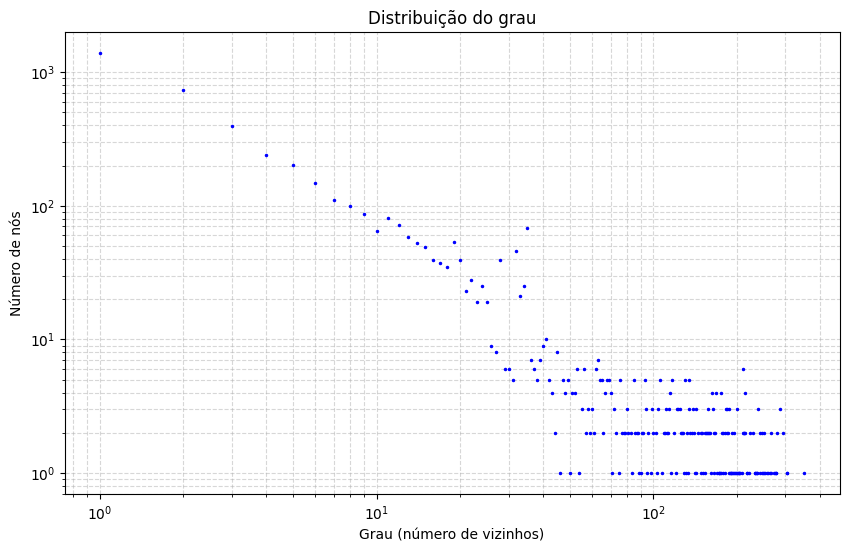

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)
x = sorted(degree_counts.keys())
y = [degree_counts[k] for k in x]


top_10 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]

print("\n=== 10 nós de maior grau ===")
for i, (node, deg) in enumerate(top_10, 1):
    nome = G.nodes[node].get('name', str(node))
    print(f"{i:2d}. Nó: {nome} | Grau: {deg}")


plt.figure(figsize=(10,6))
plt.loglog(x, y, 'b.', markersize=3)
plt.xlabel("Grau (número de vizinhos)")
plt.ylabel("Número de nós")
plt.title("Distribuição do grau")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [ ]:
import networkx as nx

n = G.number_of_nodes()
m = G.number_of_edges()

avg_degree = 2 * m / n

densidade = 2 * m / (n * (n - 1))

print(f"Nós: {n}")
print(f"Arestas: {m}")
print(f"Grau médio: {avg_degree:.4f}")
print(f"Densidade: {densidade:.6f} ({densidade:.2%})")

Nós: 4786
Arestas: 41644
Grau médio: 17.4024
Densidade: 0.003637 (0.36%)


O grau médio de indica que em média, cada jogo está conectado a outros 17 jogos. Além disso, a densidade de 0.36% apresenta uma densidade relativamente próxima a de uma rede aleatória Erdos-Renyi, contudo diferentemente de uma rede deste tipo, a cauda longa evidencia uma diferença quanto a distribuição dos graus para o caso estudado, apresentando uma grande parte dos nós com grau baixo em torno de 1 aresta e alguns nós com uma quantidade muito alta de arestas representando jogos mais populares com maior quantidade de público

### 2c. Calcule o número de componentes do grafo.

In [ ]:
components = list(nx.connected_components(G))
num_comp = len(components)
print(f"Número de componentes: {num_comp}")
comp_sizes = [len(c) for c in components]
comp_sizes.sort(reverse=True)
print(f"Maior componente: {comp_sizes[0]} nós ({comp_sizes[0]/G.number_of_nodes()*100:.1f}%)")
if num_comp > 1:
    print(f"Segundo maior componente: {comp_sizes[1]} nós")

Número de componentes: 847
Maior componente: 1350 nós (28.2%)
Segundo maior componente: 281 nós


A rede apresenta 847 componentes conexos, sendo que a componente gigante apresenta 1350 nós (28,2% do total) o que nos mostra uma rede bastante fragmentada tendo poucas componentes com um número significativo de nós e várias componentes com poucos nós, que representam jogos com nichos mais específicos e que não atenderam ao coeficiente de Jaccard estipulado que exige uma certa sobreposição do público para se ter uma ligação entre os jogos.

Extrair a componente gigante

In [ ]:
import networkx as nx

components = list(nx.connected_components(G))
largest_cc = max(components, key=len)
G_giant = G.subgraph(largest_cc).copy()
print(f"Componente gigante: {G_giant.number_of_nodes()} nós, {G_giant.number_of_edges()} arestas")

Componente gigante: 1350 nós, 30778 arestas


### 2d. Calcule o coeficiente de clusterização de cada nodo e plote a distribuição. Calcule também o coeficiente de clusterização global do grafo

Clusterização média: 0.5463
Clusterização global (transitividade): 0.5854

=== 5 nós com MAIOR coeficiente de clusterização ===
 1. Nó: Mata Hari | Coeficiente: 1.0000
 2. Nó: Weird Park Trilogy | Coeficiente: 1.0000
 3. Nó: House of 1,000 Doors - Family Secrets | Coeficiente: 1.0000
 4. Nó: Shadows: Price For Our Sins | Coeficiente: 1.0000
 5. Nó: Fighting Fantasy Legends | Coeficiente: 1.0000

=== 5 nós com MENOR coeficiente de clusterização ===
 1. Nó: ATV GP | Coeficiente: 0.0000
 2. Nó: BattleQuiz | Coeficiente: 0.0000
 3. Nó: Rest House | Coeficiente: 0.0000
 4. Nó: Clans | Coeficiente: 0.0000
 5. Nó: Pirate Pop | Coeficiente: 0.0000

Nós com coeficiente de clusterização = 1: 1357
Nós com coeficiente de clusterização = 0: 1586


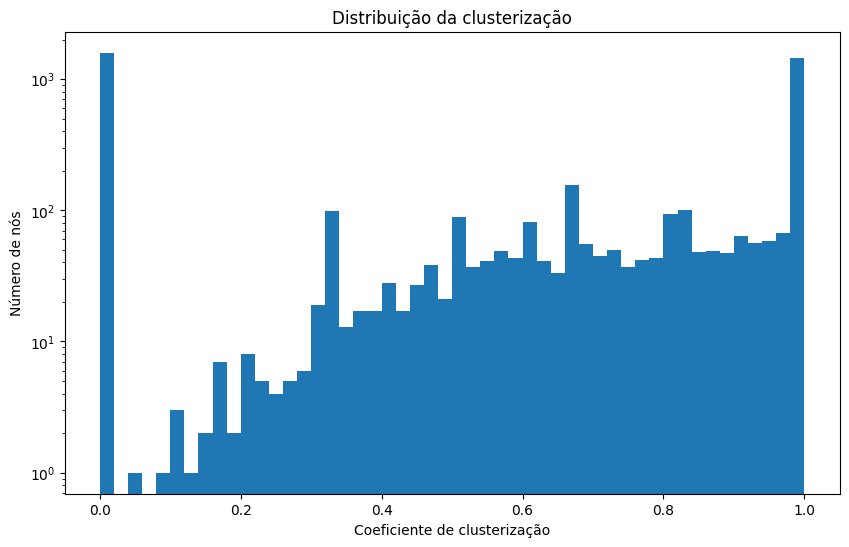

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

clust = nx.clustering(G)
clust_values = list(clust.values())
print(f"Clusterização média: {np.mean(clust_values):.4f}")
print(f"Clusterização global (transitividade): {nx.transitivity(G):.4f}")

sorted_clust = sorted(clust.items(), key=lambda x: x[1], reverse=True)

top5 = sorted_clust[:5]
bottom5 = sorted_clust[-5:]

print("\n=== 5 nós com MAIOR coeficiente de clusterização ===")
for i, (node, coef) in enumerate(top5, 1):
    nome = G.nodes[node].get('name', str(node))
    print(f"{i:2d}. Nó: {nome} | Coeficiente: {coef:.4f}")

print("\n=== 5 nós com MENOR coeficiente de clusterização ===")
for i, (node, coef) in enumerate(bottom5, 1):
    nome = G.nodes[node].get('name', str(node))
    print(f"{i:2d}. Nó: {nome} | Coeficiente: {coef:.4f}")

count_1 = sum(1 for c in clust_values if c == 1.0)
count_0 = sum(1 for c in clust_values if c == 0.0)
print(f"\nNós com coeficiente de clusterização = 1: {count_1}")
print(f"Nós com coeficiente de clusterização = 0: {count_0}")

plt.figure(figsize=(10,6))
plt.hist(clust_values, bins=50, log=True)
plt.xlabel("Coeficiente de clusterização")
plt.ylabel("Número de nós")
plt.title("Distribuição da clusterização")
plt.show()

O coeficiente de clusterização médio é 0,546 e o global é 0,585, valores consideravelmente altos quando comparados com o esperado para uma rede aleatória de mesma densidade (0,0036). Essa alta clusterização indica forte formação de triângulos na rede, coerente com a existência de comunidades bem definidas de jogos que compartilham públicos. Além disso, vemos uma alta presença de comunidades evidenciada pelo alto número de nós com o coeficiente 1 e ao mesmo tempo diversos nós que servem como ponte entre comunidades evidenciado pelos nós com coeficiente 0

### 2e.  Plote a distribuição do tamanho dos componentes do grafo.

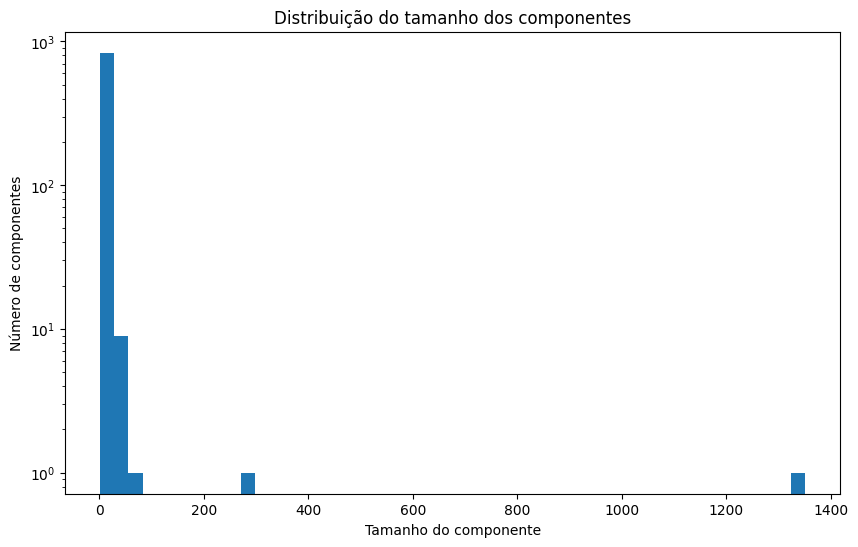

In [ ]:
if num_comp > 1:
    plt.figure(figsize=(10,6))
    plt.hist(comp_sizes, bins=50, log=True)
    plt.xlabel("Tamanho do componente")
    plt.ylabel("Número de componentes")
    plt.title("Distribuição do tamanho dos componentes")
    plt.show()

A rede possui 847 componetes, sendo a componente gigante formada por 1350 nós (28.2% da rede), as demais componentes apresentam um número de nós bem abaixo deste valor sendo a 2° maior formada por 281 nós e as demais todas abaixo de 100 nós formados por jogos mais específicos com nichos mais definidos

### 2f. Calcule o overlap da vizinhança para cada par de nodo e plote a distribuição dos valores encontrados.

Estatísticas do Overlap da Vizinhança:
  Número de arestas analisadas: 41644
  Overlap médio: 0.4730
  Desvio padrão: 0.2778
  Valor mínimo: 0.0000
  Valor máximo: 1.0000


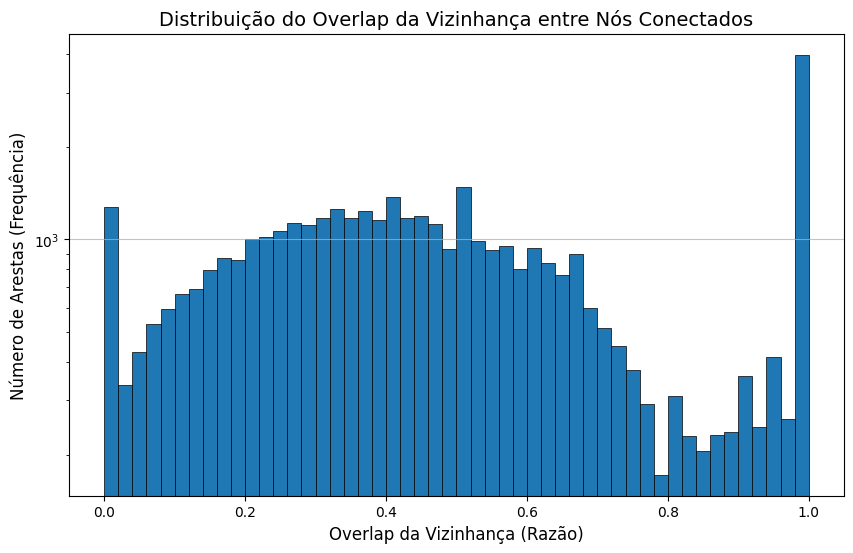

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

def neighborhood_overlap_ratio(G):
    overlap_values = {}
    for u, v in G.edges():
        common_neighbors = list(nx.common_neighbors(G, u, v))
        n_common = len(common_neighbors)

        deg_u = G.degree(u)
        deg_v = G.degree(v)

        n_union = deg_u + deg_v - n_common

        denominator = n_union - 2

        if denominator > 0:
            overlap = n_common / denominator
        else:
            overlap = 0.0

        overlap_values[(u, v)] = overlap

    return overlap_values

overlaps = neighborhood_overlap_ratio(G)

overlap_list = list(overlaps.values())
print(f"Estatísticas do Overlap da Vizinhança:")
print(f"  Número de arestas analisadas: {len(overlap_list)}")
print(f"  Overlap médio: {np.mean(overlap_list):.4f}")
print(f"  Desvio padrão: {np.std(overlap_list):.4f}")
print(f"  Valor mínimo: {min(overlap_list):.4f}")
print(f"  Valor máximo: {max(overlap_list):.4f}")

plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(overlap_list, bins=50, log=True, edgecolor='black', linewidth=0.5)
plt.xlabel("Overlap da Vizinhança (Razão)", fontsize=12)
plt.ylabel("Número de Arestas (Frequência)", fontsize=12)
plt.title("Distribuição do Overlap da Vizinhança entre Nós Conectados", fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()

O overlap médio de 0.473 indica que cerca de 47% dos vizinhos são compartilhados. É importante ressaltar os picos na razão 1.0 e 0.0 que indicam respectivamente que os dois jogos compartilham todos os seus vizinhos e jogos que não têm nenhum vizinho em comum, sendo geralmente pontes entre comunidades diferentes. Esse padrão reforça uma polarização na qual os jogos apresentam ou públicos muito semelhantes ou muito diversos.

### 2g. Calcule a distância média e a distribuição das distâncias de todos os nodos da rede.

Como a rede formada apresenta diversas componentes menores o cálculo das distâncias entre os nós da rede e a distância média foram calculados considerando-se apenas a componente gigante

Componente gigante: 1350 nós, 30778 arestas
Distância média: 5.9503

Distribuição das distâncias:
  d=1: 61556 pares (3.38%)
  d=2: 289294 pares (15.89%)
  d=3: 313486 pares (17.21%)
  d=4: 231786 pares (12.73%)
  d=5: 155986 pares (8.57%)
  d=6: 101092 pares (5.55%)
  d=7: 82788 pares (4.55%)
  d=8: 66704 pares (3.66%)
  d=9: 74926 pares (4.11%)
  d=10: 118570 pares (6.51%)
  d=11: 127964 pares (7.03%)
  d=12: 91714 pares (5.04%)
  d=13: 51780 pares (2.84%)
  d=14: 28366 pares (1.56%)
  d=15: 15450 pares (0.85%)
  d=16: 6746 pares (0.37%)
  d=17: 2262 pares (0.12%)
  d=18: 556 pares (0.03%)
  d=19: 116 pares (0.01%)
  d=20: 8 pares (0.00%)


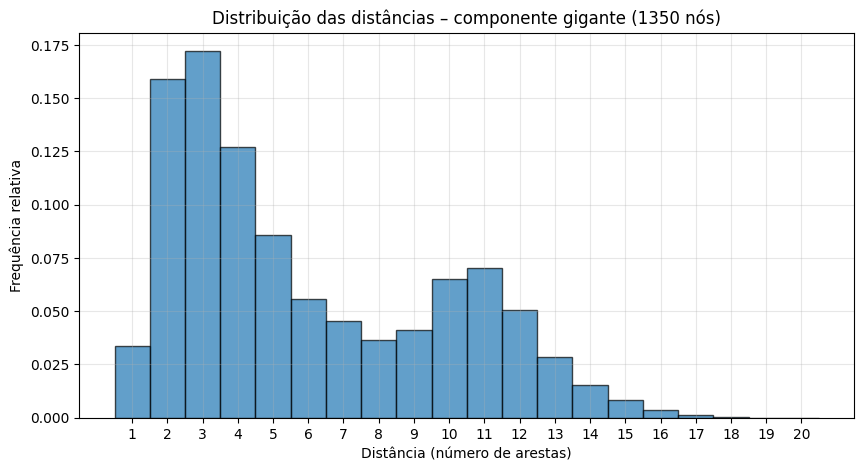


Maior distância (diâmetro): 20
Distância média: 5.9503
Desvio padrão: 3.7888


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

print(f"Componente gigante: {G_giant.number_of_nodes()} nós, {G_giant.number_of_edges()} arestas")

avg_dist = nx.average_shortest_path_length(G_giant)
print(f"Distância média: {avg_dist:.4f}")

all_lengths = dict(nx.all_pairs_shortest_path_length(G_giant))

distances = []
for source, targets in all_lengths.items():
    for target, d in targets.items():
        if source != target:
            distances.append(d)

dist_counter = Counter(distances)
total_pares = len(distances)
print("\nDistribuição das distâncias:")
for d in sorted(dist_counter.keys()):
    print(f"  d={d}: {dist_counter[d]} pares ({dist_counter[d]/total_pares:.2%})")

plt.figure(figsize=(10,5))
bins = np.arange(0.5, max(distances)+1.5, 1)
plt.hist(distances, bins=bins, density=True, alpha=0.7, edgecolor='black')
plt.xlabel("Distância (número de arestas)")
plt.ylabel("Frequência relativa")
plt.title(f"Distribuição das distâncias – componente gigante ({G_giant.number_of_nodes()} nós)")
plt.xticks(range(1, max(distances)+1))
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMaior distância (diâmetro): {max(distances)}")
print(f"Distância média: {np.mean(distances):.4f}")
print(f"Desvio padrão: {np.std(distances):.4f}")

No componente gigante (1.350 nós), a distância média entre quaisquer dois jogos é 5,95. A distribuição das distâncias apresenta um pico em d=3 (17,2% dos pares), decaindo gradualmente. Essa forma indica que a rede é composta por comunidades densas e bem conectadas internamente (distâncias curtas), enquanto a comunicação entre diferentes comunidades requer caminhos mais longos. O valor da distância média, embora baixo em termos absolutos, é relativamente alto, revelando uma estrutura fortemente compartimentada – consistente com a alta clusterização e a fragmentação observadas anteriormente. Contudo, ainda é consistente como observação do fenômeno de small world.

### 2h.  Plote uma visualização do grafo ou de parte, ex. um componente, do grafo caso ele seja muito grande.

Para esta etapa foi considerada apenas a componente gigante do grafo composta por 1350 nós e 30778 arestas e a vizualização foi feita usando o Gephi na versão para desktop. Abaixo está a imagem exportada do gephi e codificada pelo colab, além disso no repositório está o arquivo gexf (componente_gigante.gexf) com as configurações usadas para a exibição desta imagem. Vale ressaltar que para apresentar o padrão desta imagem foi ajustado o tamanho dos nós e arestas bem como adicionado padrões de cores, para os nós o padrão vem do uso da função do próprio gephi de detecção de comunidade o que resulta no padrão observado com as cores indicando essa detecção feita e a distribuição usada foi a "Fruchterman Reingold" escolhida empiricamente buscando apresentar uma vizualização mais proveitosa.

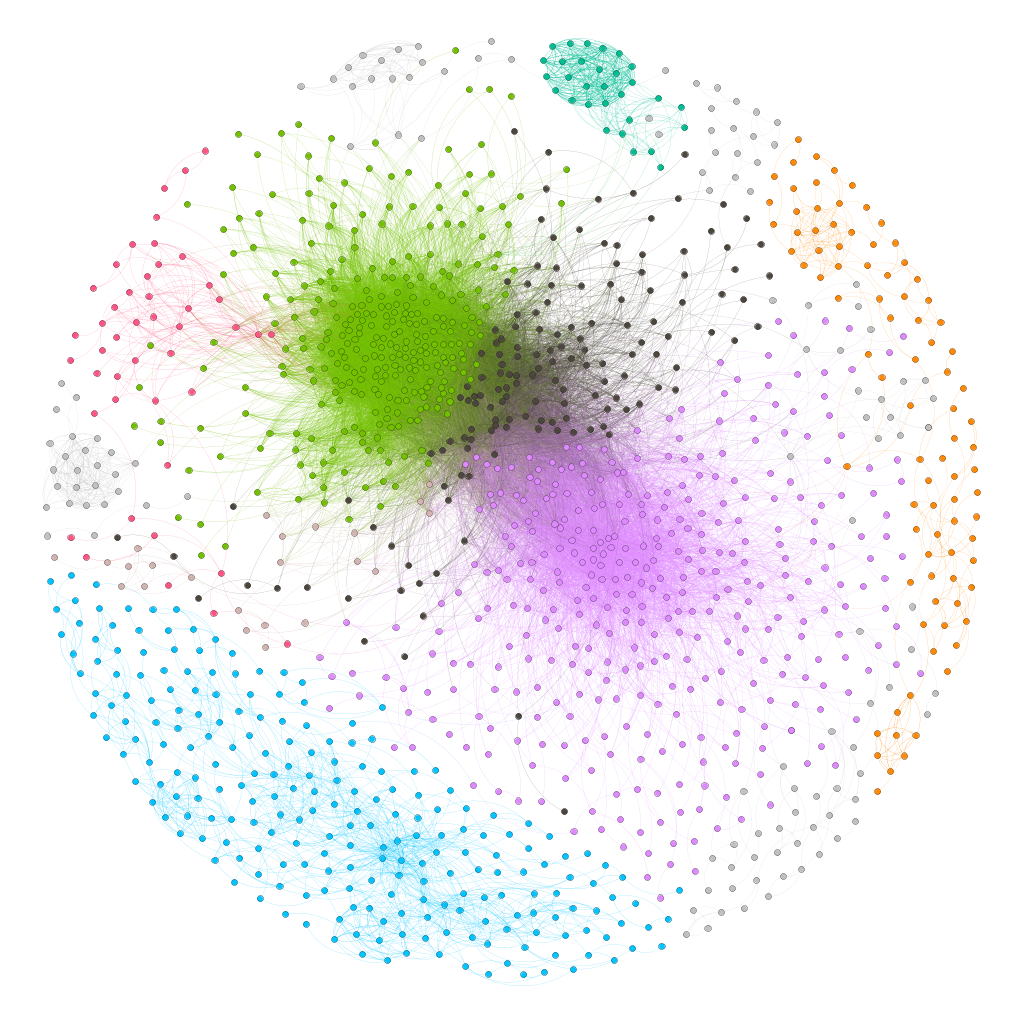

## Conclusão

A rede montada representa uma rede de similaridade entre jogos baseando-se na sobreposição de usuários, podendo ser visto como uma espécie de simulação de uma rede para recomendação de jogos. Nesse contexto, é importante ressaltar que o trabalho adotou métricas (intervalo de número de usuários e coeficiente de Jaccard) que influenciam na presença dos jogos na rede e na ligação (arestas) entre os jogos, sendo uma rede que exclui uma vasta gama de jogos pouco populares e ao mesmo tempo exclui uma parcela de jogos extremamente populares.

Esta rede apresenta alguns comportamentos esperados para este tipo de rede visto que a popularidade dos jogos impacta diretamente o grau dos nós, sendo os jogos mais populares tendem a apresentar mais conexões enquanto os menos populares tendem a apresentar menos conexões e estas costumam estar associadas à um nicho e/ou jogos de uma mesma franquia, fator esse também observado através dos coeficientes de clusterização que indicam uma forte formação de comunidades e ao mesmo tempo uma grande quantidade de nós ponte.

Além disso, apesar das distâncias entre nós apresentarem uma faixa grande (1 a 20) ainda é nítido a presença do efeito de small world visto que a distância média é próxima a 6 e a maior parte dos pares apresentam uma distância igual ou inferior a esse limiar.



# Salvar grafo

os grafos gerados (grafo completo e componente gigante) podem ser salvos no drive usando os comandos abaixo alterando a pasta de destino e o nome, tendo a opção de salvar no formato gexf ou pkl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import networkx as nx
import pickle
from google.colab import drive
import os
pasta = '/content/drive/MyDrive/Steam - redes complexas' # pasta destino (alterar conforme necessário)
os.makedirs(pasta, exist_ok=True)
nx.write_gexf(G_giant, os.path.join(pasta, 'componente_gigante_2.gexf'))
nx.write_gexf(G, os.path.join(pasta, 'grafo_completo_2.gexf'))

In [ ]:
with open(os.path.join(pasta, 'componente_gigante_2.pkl'), 'wb') as f:
    pickle.dump(G_giant, f, pickle.HIGHEST_PROTOCOL)

with open(os.path.join(pasta, 'grafo_completo_2.pkl'), 'wb') as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)